# WTI-Brent cointegration in R: an independent check and the Johansen test

The pairs-trading notebook relies on the Engle-Granger test computed by the Python package `backtest_engine`. This notebook repeats the
analysis with **R** on the same official EIA spot prices (FRED), compares the statistics, and adds tests that are standard in R:

| Quantity | R implementation | Python notebook |
| --- | --- | --- |
| Engle-Granger: OLS hedge ratio and ADF test on the residuals | `lm`, `urca::ur.df` | `wti_brent_kalman_pairs` |
| Half-life of the spread | AR(1) regression | same notebook |
| Phillips-Ouliaris residual-based test | `tseries::po.test` | new in R |
| Johansen trace test (system approach, rank and cointegrating vector) | `urca::ca.jo` | new in R |

Samples: 1988-2009 (in sample for the strategy), 2010-2025 (out of sample) and the full period.

**Requirements.** R 4.2 or later with the packages in `r/install_packages.R` and the IRkernel (see the README). The comparison cells
call the Python package if it is installed (`PYTHON` environment variable, `.venv` in the repository or `python3` on the PATH);
otherwise they are skipped. Data are downloaded into `data/raw/r/`.

In [1]:
suppressPackageStartupMessages({
  library(jsonlite)
  library(ggplot2)
  library(urca)
  library(tseries)
})
options(width = 120, repr.plot.width = 10, repr.plot.height = 4.6, repr.plot.res = 110, scipen = 6)

# Repository root: the folder that contains scripts/backtest_engine.
find_root <- function() {
  d <- normalizePath(getwd())
  repeat {
    if (dir.exists(file.path(d, "scripts", "backtest_engine"))) return(d)
    parent <- dirname(d)
    if (parent == d) stop("run the notebook inside the repository")
    d <- parent
  }
}
ROOT <- find_root()
CACHE <- file.path(ROOT, "data", "raw", "r")   # ignored by Git
dir.create(CACHE, recursive = TRUE, showWarnings = FALSE)

cached_download <- function(url, name) {
  path <- file.path(CACHE, name)
  if (!file.exists(path)) download.file(url, path, quiet = TRUE, mode = "wb")
  path
}

# Results of the Python/C++ engine for the comparison. The code is run with the interpreter in the
# PYTHON environment variable, or .venv in the repository, or python3 on the PATH; it must print JSON.
python_json <- function(code) {
  candidates <- c(Sys.getenv("PYTHON"), file.path(ROOT, ".venv", "bin", "python"),
                  file.path(ROOT, ".venv", "Scripts", "python.exe"), Sys.which("python3"), Sys.which("python"))
  candidates <- candidates[nzchar(candidates) & file.exists(candidates)]
  if (length(candidates) == 0) { message("Python not found: comparison skipped"); return(NULL) }
  script <- tempfile(fileext = ".py")
  writeLines(c("import json, os, sys", sprintf("os.chdir(%s)", deparse(ROOT)), code), script)
  out <- suppressWarnings(system2(candidates[1], script, stdout = TRUE, stderr = FALSE))
  if (!is.null(attr(out, "status")) || length(out) == 0) {
    message("the Python package backtest_engine is not available: comparison skipped"); return(NULL)
  }
  fromJSON(paste(out, collapse = "\n"))
}

compare <- function(r, py, label = names(r)) {
  data.frame(quantity = label, R = signif(r, 10), Python = signif(py, 10),
             `abs. difference` = signif(abs(r - py), 3), check.names = FALSE, row.names = NULL)
}

COLORS <- c("#2a78d6", "#eb6834", "#1baf7a", "#eda100")
theme_set(theme_minimal(base_size = 12) +
          theme(panel.grid.minor = element_blank(), plot.title.position = "plot",
                plot.title = element_text(face = "bold"), legend.position = "top"))
cat(R.version.string, "| repository:", basename(ROOT), "\n")

fred <- function(id) {
  f <- read.csv(cached_download(paste0("https://fred.stlouisfed.org/graph/fredgraph.csv?id=", id), paste0(id, ".csv")),
                na.strings = ".")
  names(f) <- c("date", id)
  f$date <- as.Date(f$date)
  f
}
SAMPLES <- list("1988-2009" = c("1988-01-01", "2009-12-31"), "2010-2025" = c("2010-01-01", "2025-12-31"),
                "1988-2025" = c("1988-01-01", "2025-12-31"))

R version 4.3.3 (2024-02-29) | repository: Algorithmic-trading 


## 1. Data

In [2]:
prices <- merge(fred("DCOILWTICO"), fred("DCOILBRENTEU"), by = "date")
prices <- prices[complete.cases(prices) & prices$date >= as.Date("1988-01-01") & prices$date <= as.Date("2025-12-31"), ]
names(prices) <- c("date", "WTI", "Brent")
cat(sprintf("%s common days from %s to %s\n", format(nrow(prices), big.mark = ","), min(prices$date), max(prices$date)))
summary(prices[, c("WTI", "Brent")])

8,075 common days from 1988-01-04 to 2025-12-31


      WTI             Brent       
 Min.   :-36.98   Min.   :  9.10  
 1st Qu.: 22.55   1st Qu.: 21.15  
 Median : 52.43   Median : 55.26  
 Mean   : 53.32   Mean   : 55.45  
 3rd Qu.: 75.56   3rd Qu.: 77.84  
 Max.   :145.31   Max.   :143.95  

## 2. Engle-Granger and Phillips-Ouliaris tests

Step 1: OLS of WTI on a constant and Brent. Step 2: ADF regression of the residuals without deterministic terms,
$\\Delta e_t = \\phi\\, e_{t-1} + \\sum_{i=1}^{p} c_i \\Delta e_{t-i} + u_t$. To compare like with like, `ur.df` is run with the number of lags
selected by the Python package (AIC on a common sample, as in statsmodels); the lag chosen by `ur.df`'s own AIC search is shown too.
Critical values for residual-based tests are those of MacKinnon (2010) for two variables, about -3.34 at 5% in large samples.
`po.test` interpolates its p-values in a table bounded at 0.01 and 0.15, so 0.01 means "0.01 or less".

In [3]:
py <- python_json('
from backtest_engine import cointegration as ci, data
p = data.load_fred(["DCOILWTICO", "DCOILBRENTEU"], start="1988-01-01", end="2025-12-31").dropna()
samples = {"1988-2009": ("1988", "2009"), "2010-2025": ("2010", "2025"), "1988-2025": ("1988", "2025")}
out = {}
for name, (a, b) in samples.items():
    s = p.loc[a:b]
    eg = ci.engle_granger(s["DCOILWTICO"], s["DCOILBRENTEU"])
    out[name] = {"n": len(s), "alpha": eg["alpha"], "beta": eg["beta"], "statistic": eg["statistic"], "lags": eg["lags"],
                 "crit5": eg["critical_values"]["5%"], "half_life": ci.half_life(eg["residuals"])}
print(json.dumps(out))
')
rows <- list()
for (name in names(SAMPLES)) {
  s <- prices[prices$date >= as.Date(SAMPLES[[name]][1]) & prices$date <= as.Date(SAMPLES[[name]][2]), ]
  ols <- lm(WTI ~ Brent, data = s)
  e <- residuals(ols)
  max_lag <- min(ceiling(12 * (length(e) / 100)^0.25), length(e) %/% 2 - 1)
  lags <- if (!is.null(py)) py[[name]]$lags else max_lag
  adf_fixed <- ur.df(e, type = "none", lags = lags, selectlags = "Fixed")
  adf_aic <- ur.df(e, type = "none", lags = max_lag, selectlags = "AIC")
  ar <- lm(diff(e) ~ head(e, -1))
  b_ar <- coef(ar)[2]
  po <- suppressWarnings(po.test(cbind(s$WTI, s$Brent)))
  row <- data.frame(sample = name, n = nrow(s), beta = coef(ols)[2], `ADF statistic` = adf_fixed@teststat[1], lags = lags,
                    `ADF statistic, ur.df AIC lags` = adf_aic@teststat[1], `half-life (days)` = -log(2) / log1p(b_ar),
                    `Phillips-Ouliaris` = unname(po$statistic), `PO p-value` = po$p.value, check.names = FALSE)
  if (!is.null(py)) {
    row$`beta, Python` <- py[[name]]$beta
    row$`ADF statistic, Python` <- py[[name]]$statistic
    row$`half-life, Python` <- py[[name]]$half_life
    row$`5% critical value` <- py[[name]]$crit5
  }
  rows[[name]] <- row
}
eg <- do.call(rbind, rows); rownames(eg) <- NULL
eg

sample,n,beta,ADF statistic,lags,"ADF statistic, ur.df AIC lags",half-life (days),Phillips-Ouliaris,PO p-value,"beta, Python","ADF statistic, Python","half-life, Python",5% critical value
<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1988-2009,4155,0.9995501,-6.860717,31,-6.860717,3.304129,-1722.8224,0.01,0.9995501,-6.860717,3.304129,-3.337612
2010-2025,3920,0.8471098,-4.773156,19,-4.829256,10.462222,-304.9711,0.01,0.8471098,-4.773156,10.462222,-3.337697
1988-2025,8075,0.8884165,-4.901860,28,-4.900770,13.449148,-705.7018,0.01,0.8884165,-4.901860,13.449148,-3.336890


## 3. Johansen trace test (R only)

The Johansen procedure treats WTI and Brent symmetrically in a VAR (two lags in levels, constant restricted to the cointegrating
relation) and tests the number of cointegrating relations $r$: first $r = 0$ against $r \\ge 1$, then $r \\le 1$ against $r = 2$.
A rejection of $r = 0$ with no rejection of $r \\le 1$ indicates one cointegrating relation; its normalised vector gives the long-run
hedge ratio.

In [4]:
jo_rows <- list()
for (name in names(SAMPLES)) {
  s <- prices[prices$date >= as.Date(SAMPLES[[name]][1]) & prices$date <= as.Date(SAMPLES[[name]][2]), c("WTI", "Brent")]
  jo <- ca.jo(s, type = "trace", ecdet = "const", K = 2, spec = "transitory")
  stat <- rev(jo@teststat); cv5 <- rev(jo@cval[, "5pct"])
  v <- jo@V[, 1] / jo@V[1, 1]
  jo_rows[[name]] <- data.frame(sample = name, `trace r = 0` = stat[1], `5% c.v. r = 0` = cv5[1],
                                `trace r <= 1` = stat[2], `5% c.v. r <= 1` = cv5[2],
                                `relations at 5%` = sum(stat > cv5), `long-run hedge ratio` = -v[2], check.names = FALSE)
}
johansen <- do.call(rbind, jo_rows); rownames(johansen) <- NULL
johansen

sample,trace r = 0,5% c.v. r = 0,trace r <= 1,5% c.v. r <= 1,relations at 5%,long-run hedge ratio
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1988-2009,215.22526,19.96,1.655447,9.24,1,1.0011909
2010-2025,62.75926,19.96,4.472073,9.24,1,0.8481620
1988-2025,97.77903,19.96,4.562824,9.24,1,0.8904914


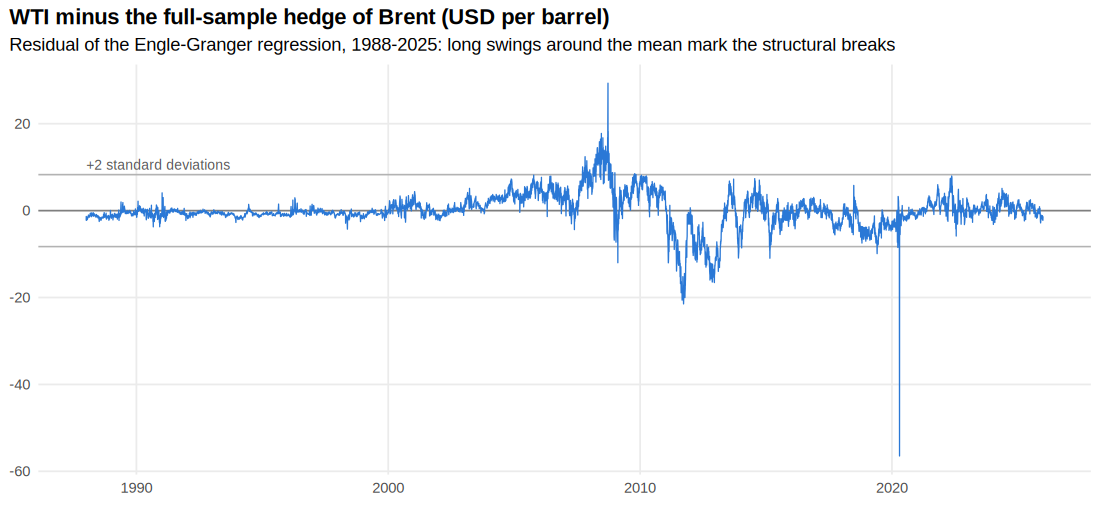

In [5]:
full <- prices
full$spread <- residuals(lm(WTI ~ Brent, data = full))
sd_spread <- sd(full$spread)
ggplot(full, aes(date, spread)) +
  geom_hline(yintercept = c(-2, 2) * sd_spread, colour = "grey70") + geom_hline(yintercept = 0, colour = "grey50") +
  geom_line(colour = COLORS[1], linewidth = 0.4) +
  annotate("text", x = min(full$date), y = 2 * sd_spread, label = "+2 standard deviations", hjust = 0, vjust = -0.5, size = 3.2,
           colour = "grey35") +
  labs(title = "WTI minus the full-sample hedge of Brent (USD per barrel)",
       subtitle = "Residual of the Engle-Granger regression, 1988-2025: long swings around the mean mark the structural breaks",
       x = NULL, y = NULL)

## 4. Conclusions

- With the same lag length, `urca::ur.df` reproduces the Python ADF statistic on the Engle-Granger residuals, and the hedge ratios
  and half-lives agree: the cointegration evidence reported in the pairs notebook does not depend on the implementation.
- The Phillips-Ouliaris and Johansen tests give a second and third opinion. In the run shown all three tests find one cointegrating
  relation in each sample, but the long-run hedge ratio moves from about 1.00 in 1988-2009 to about 0.85 in 2010-2025 and the
  half-life of the spread lengthens: the relation persists while its parameters change, which is why the strategy re-estimates the
  hedge ratio with a Kalman filter and its hyperparameters year by year.

### References

- Engle, R. F. and Granger, C. W. J. (1987). Co-integration and error correction. *Econometrica*, 55(2), 251-276.
- Johansen, S. (1991). Estimation and hypothesis testing of cointegration vectors in Gaussian vector autoregressive models. *Econometrica*, 59(6), 1551-1580.
- MacKinnon, J. G. (2010). Critical values for cointegration tests. Queen's Economics Department Working Paper 1227.
- Pfaff, B. (2008). *Analysis of Integrated and Cointegrated Time Series with R*. Springer.
- Phillips, P. C. B. and Ouliaris, S. (1990). Asymptotic properties of residual based tests for cointegration. *Econometrica*, 58(1), 165-193.